In [5]:
import kagglehub
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
        print(os.path.join(dirname))

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Convolution2D,MaxPooling2D,Flatten #action detectionimport tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import HTML

/kaggle/input


In [6]:
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("kshitij192/cars-image-dataset")
print("Path to dataset files:", path)

IMAGE_SIZE = 128

# Define the training path (assuming the download contains a 'Cars Dataset/train' folder)
train_path = os.path.join(path, 'Cars Dataset', 'train')

train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
        train_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        class_mode="sparse"
)

Using Colab cache for faster access to the 'cars-image-dataset' dataset.
Path to dataset files: /kaggle/input/cars-image-dataset
Found 3352 images belonging to 7 classes.


Display 5 sample dari kelas: 'Audi'


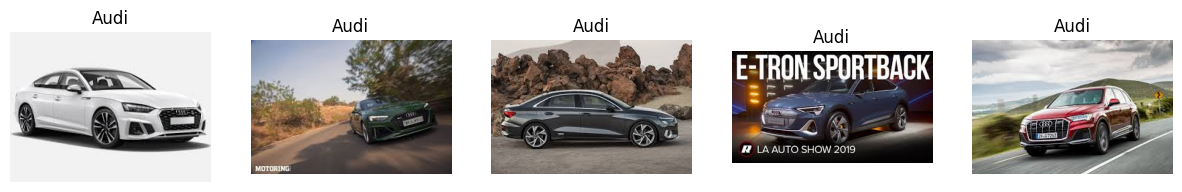

Display 5 sample dari kelas: 'Hyundai Creta'


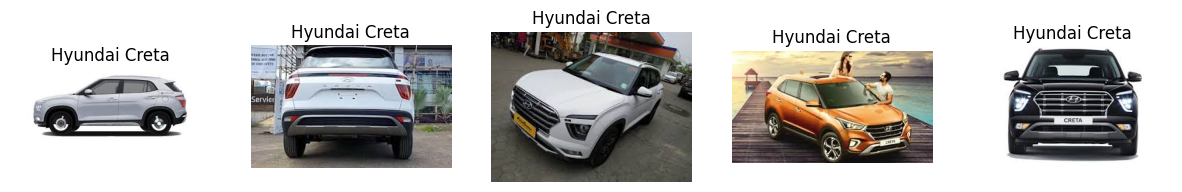

Display 5 sample dari kelas: 'Mahindra Scorpio'


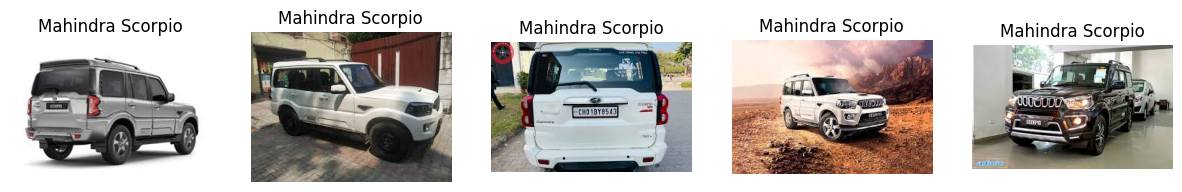

Display 5 sample dari kelas: 'Rolls Royce'


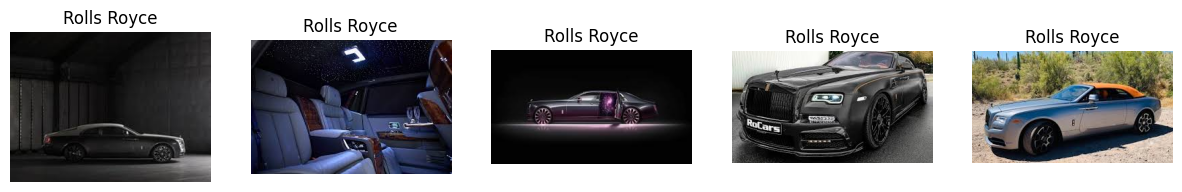

Display 5 sample dari kelas: 'Swift'


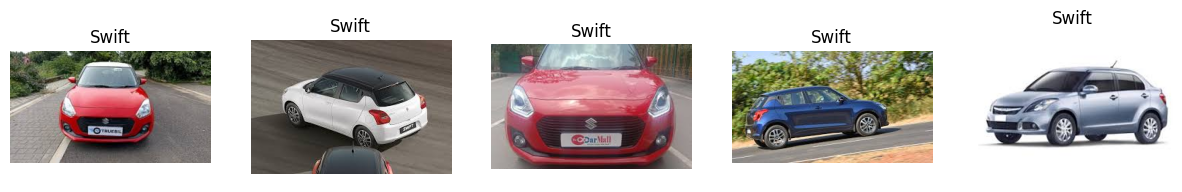

Display 5 sample dari kelas: 'Tata Safari'


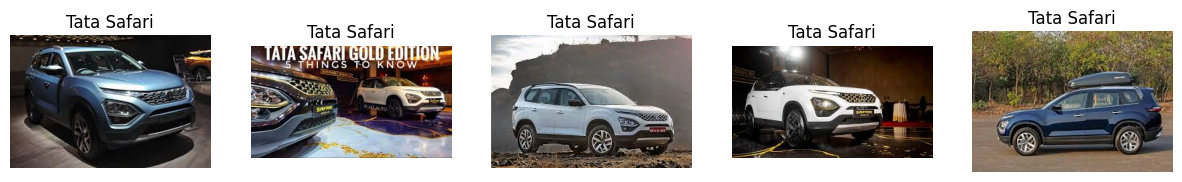

Display 5 sample dari kelas: 'Toyota Innova'


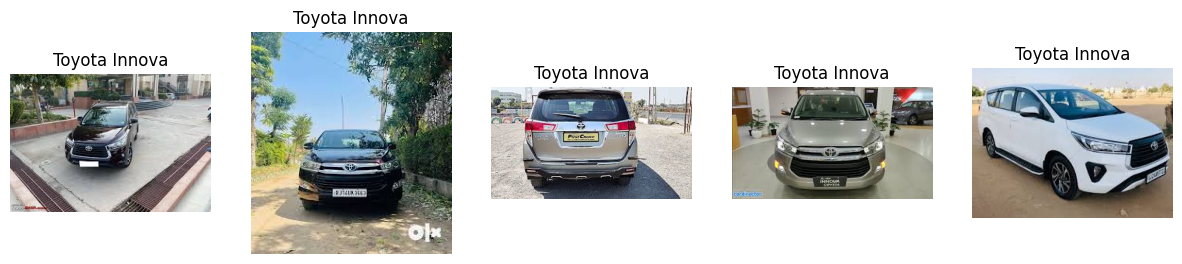

In [7]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# Define dataset_root and nama_kelas
dataset_root = os.path.join(path, 'Cars Dataset', 'train') # Assuming you want to display from the training set
nama_kelas = list(train_generator.class_indices.keys())

for class_name in nama_kelas:
    class_path = os.path.join(dataset_root, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    random.shuffle(images)

    print(f"Display 5 sample dari kelas: '{class_name}'")
    plt.figure(figsize=(15, 3))
    for i in range(min(5, len(images))):
        img_path = os.path.join(class_path, images[i])
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
img_height = 224
img_width = 224
batch_size = 32

# Data augmentation and preprocessing for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    rotation_range=20,       # Rotate images by up to 20 degrees
    horizontal_flip=True,    # Randomly flip images horizontally
    validation_split=0.2     # Split 20% of data for validation
)

# Only rescale for validation data (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1]
    validation_split=0.2     # Use the same split for validation
)

# Load training data from directory
train_generator = train_datagen.flow_from_directory(
    dataset_root,            # Path to your dataset root directory
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical', # Use 'categorical' for multi-class classification
    subset='training',        # Specify this is the training subset
    seed=42                   # For reproducible results
)

# Load validation data from directory
validation_generator = val_datagen.flow_from_directory(
    dataset_root,            # Path to your dataset root directory
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical', # Use 'categorical' for multi-class classification
    subset='validation',      # Specify this is the validation subset
    seed=42                   # For reproducible results
)

print(f"Number of training samples: {train_generator.samples}")
print(f"Number of validation samples: {validation_generator.samples}")
print(f"Classes: {train_generator.class_indices}")


Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Number of training samples: 2684
Number of validation samples: 668
Classes: {'Audi': 0, 'Hyundai Creta': 1, 'Mahindra Scorpio': 2, 'Rolls Royce': 3, 'Swift': 4, 'Tata Safari': 5, 'Toyota Innova': 6}


In [9]:
count=0
for image_batch, label_batch in train_generator:
#     print(label_batch)
    print(image_batch[0])
    break

[[[0.9981966  0.9981966  0.9981966 ]
  [0.99891937 0.99891937 0.99891937]
  [0.99964213 0.99964213 0.99964213]
  ...
  [0.5473506  0.51597804 0.5081349 ]
  [0.54901963 0.5176471  0.50980395]
  [0.55113775 0.5197652  0.51192206]]

 [[0.9960785  0.9960785  0.9960785 ]
  [0.9960785  0.9960785  0.9960785 ]
  [0.9960785  0.9960785  0.9960785 ]
  ...
  [0.5480733  0.51670074 0.5088576 ]
  [0.54901963 0.5176471  0.50980395]
  [0.5518605  0.52048796 0.5126448 ]]

 [[0.99774754 0.99774754 0.99774754]
  [0.99702483 0.99702483 0.99702483]
  [0.99630207 0.99630207 0.99630207]
  ...
  [0.54879606 0.5174235  0.5095804 ]
  [0.54901963 0.5176471  0.50980395]
  [0.5525833  0.52121073 0.5133676 ]]

 ...

 [[0.7518674  0.74794585 0.7401027 ]
  [0.7391413  0.7352197  0.7273766 ]
  [0.71439624 0.71047467 0.70263153]
  ...
  [0.38431376 0.34509805 0.34117648]
  [0.38431376 0.34509805 0.34117648]
  [0.38431376 0.34509805 0.34117648]]

 [[0.7496992  0.7457776  0.73793447]
  [0.734082   0.7301604  0.7223172 ]


In [10]:
class_names = list(train_generator.class_indices.keys())
class_names

['Audi',
 'Hyundai Creta',
 'Mahindra Scorpio',
 'Rolls Royce',
 'Swift',
 'Tata Safari',
 'Toyota Innova']

In [11]:
test_path = os.path.join(path, 'Cars Dataset', 'test')

test_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)

test_generator = test_datagen.flow_from_directory(
        test_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        class_mode="sparse"
)

Found 813 images belonging to 7 classes.


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Get the number of classes from the generator
num_classes = train_generator.num_classes

# Load the pre-trained MobileNetV2 model without the top classification layer
base_model = MobileNetV2(input_shape=(img_height, img_width, 3),
                          include_top=False,
                          weights='imagenet')

# Freeze the base model layers so they are not updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add a new classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Additional dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with softmax for multi-class classification

# Create the new model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
print("Train samples:", train_generator.samples)
print("Train batch size:", train_generator.batch_size)
print("Train steps:", len(train_generator))

print("Validation samples:", validation_generator.samples)
print("Validation batch size:", validation_generator.batch_size)
print("Validation steps:", len(validation_generator))

Train samples: 2684
Train batch size: 32
Train steps: 84
Validation samples: 668
Validation batch size: 32
Validation steps: 21


In [18]:
import os

# Using train_path which was defined in a previous cell
for root, dirs, files in os.walk(train_path):
    # Only print directories that actually contain files
    if files:
        print(f"{root}: {len(files)} files")

/kaggle/input/cars-image-dataset/Cars Dataset/train/Hyundai Creta: 271 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Tata Safari: 441 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Swift: 424 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Mahindra Scorpio: 316 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Toyota Innova: 775 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Rolls Royce: 311 files
/kaggle/input/cars-image-dataset/Cars Dataset/train/Audi: 814 files


In [22]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.8580 - loss: 0.4195 - val_accuracy: 0.8189 - val_loss: 0.5185
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.8849 - loss: 0.3601 - val_accuracy: 0.8249 - val_loss: 0.4836
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.9005 - loss: 0.3221 - val_accuracy: 0.8578 - val_loss: 0.4207
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9113 - loss: 0.2994 - val_accuracy: 0.8473 - val_loss: 0.4563
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9080 - loss: 0.2783 - val_accuracy: 0.8668 - val_loss: 0.4064
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9139 - loss: 0.2540 - val_accuracy: 0.8503 - val_loss: 0.4707
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.9300 - loss: 0.2108 - val_accuracy: 0.8743 - val_loss: 0.4069
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.9378 - loss: 0.1974 - val_accuracy: 0.8698 - v

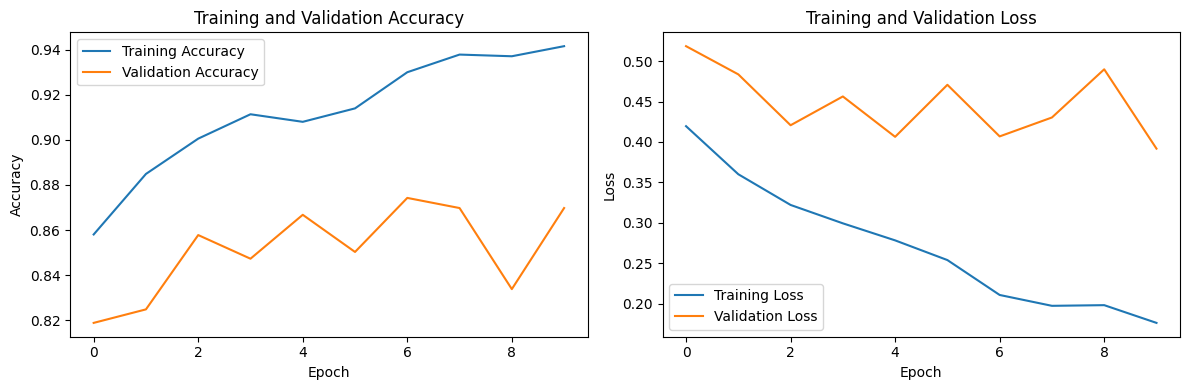

In [23]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8698 - loss: 0.3918
Validation Loss: 0.3918
Validation Accuracy: 0.8698


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


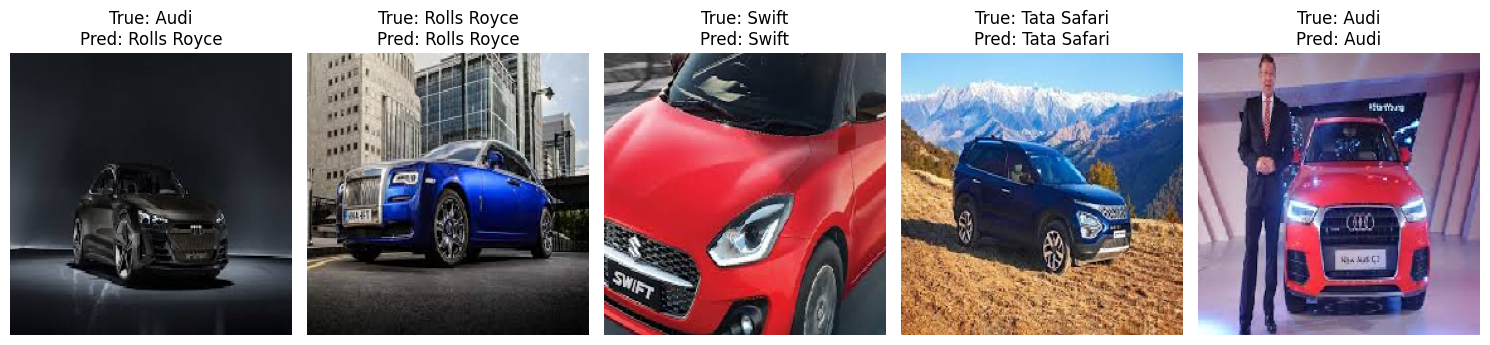

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Get a batch of images and labels from the validation generator
x_val, y_val = next(validation_generator)

# Get class names from the generator
class_names = list(validation_generator.class_indices.keys())

plt.figure(figsize=(15, 8))

# Display a few samples and their predictions
for i in range(5):
    img_array = x_val[i]
    true_label_idx = np.argmax(y_val[i])
    true_label = class_names[true_label_idx]

    # Make prediction
    prediction = model.predict(np.expand_dims(img_array, axis=0))
    predicted_label_idx = np.argmax(prediction)
    predicted_label = class_names[predicted_label_idx]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img_array)
    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Corrected Classification Report:
                  precision    recall  f1-score   support

            Audi       0.89      0.83      0.86       162
   Hyundai Creta       0.90      0.67      0.77        54
Mahindra Scorpio       0.94      0.9

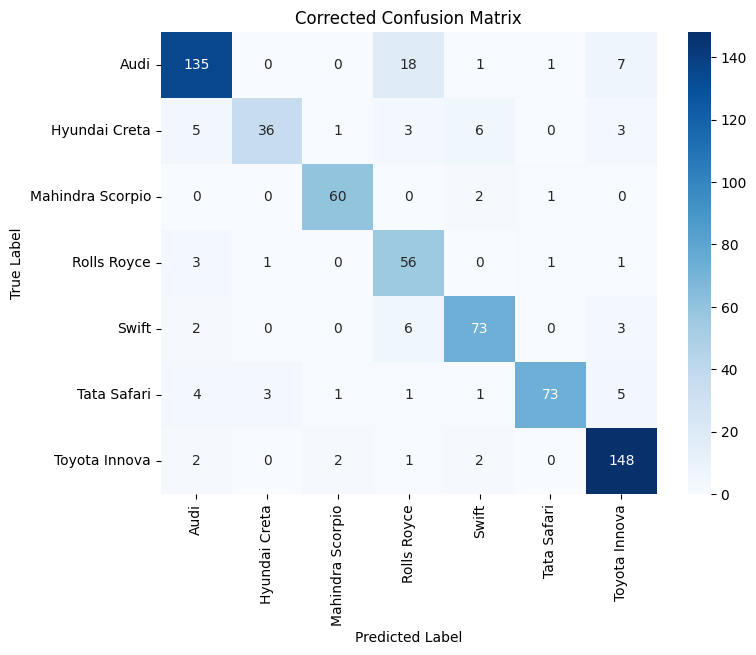

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reset the validation generator
validation_generator.reset()

# Initialize lists to store true labels and predictions
all_true_labels = []
all_predictions = []

# Iterate through the validation generator to collect true labels and make predictions
num_validation_samples = validation_generator.samples
batch_size = validation_generator.batch_size
steps_per_epoch = np.ceil(num_validation_samples / batch_size)

for i in range(int(steps_per_epoch)):
    images_batch, labels_batch = next(validation_generator)

    # Store true labels (convert from one-hot encoding if necessary)
    all_true_labels.extend(np.argmax(labels_batch, axis=1))

    # Get model predictions for the current batch
    predictions_batch = model.predict(images_batch)
    all_predictions.extend(np.argmax(predictions_batch, axis=1))

# Convert lists to numpy arrays
y_true_aligned = np.array(all_true_labels)
y_pred_aligned = np.array(all_predictions)

# Get class names from the generator in the correct order
class_labels = list(validation_generator.class_indices.keys())

print("Corrected Classification Report:")
print(classification_report(y_true_aligned, y_pred_aligned, target_names=class_labels))

# Generate Confusion Matrix
cm_aligned = confusion_matrix(y_true_aligned, y_pred_aligned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_aligned, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Corrected Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [29]:
print(class_names)
print(model.output_shape)

['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
(None, 7)


In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

# Ambil nama kelas SEKALI di luar fungsi
class_names = list(validation_generator.class_indices.keys())

print("Classes:", class_names)

def predict_image(image):

    if image is None:
        return {"Upload gambar terlebih dahulu": 1.0}

    image = Image.fromarray(image.astype(np.uint8))
    image = image.resize((img_width, img_height))

    image_array = np.asarray(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    predictions = model.predict(image_array, verbose=0)
    probabilities = predictions[0]

    result = {
        class_names[i]: float(probabilities[i])
        for i in range(len(class_names))
    }

    return result

iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=gr.Label(num_top_classes=3),
    title="Car Classification",
    description="Upload an image of a car to classify."
)

iface.launch(debug=True, share=True)

Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d1c821602b60e437bf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error